# Samlet notebook: Manglende data, imputering, relationelle databaser og støj i tidsserier

**Miniprojekt – AI og Data**  
Denne notebook samler arbejdet fra *Notebook 1* og *Notebook 2* i én rapportlignende analyse. Strukturen følger samme idé som PDF-rapporten: først en kort faglig ramme, derefter dataanalyse, metodevalg, implementering, evaluering og delkonklusioner.

## Opgavespørgsmål der besvares

### Del 1 – Manglende data og relationelle databaser
1. Identificér typer af datamangel.
2. Implementér/anvend minimum to dataimputeringsmetoder.
3. Sammenlign metoderne, bl.a. ved brug af en classifier med/uden imputering.
4. Strukturér data i minimum to relationelle tabeller/databaser.

### Del 2 – Støj i tidsseriedata
1. Vurdér graden af støj for tidsseriedata gennem datavisualisering.
2. Anvend passende præprocessering med vinduesmetoden.
3. Plot data før og efter præprocessering.

## Datasæt

- `Sales_with_NaNs_v1.3.csv`: salgsdata med manglende værdier.
- `Sales_without_NaNs_v1.3.csv`: referenceversion uden NaNs, kun brugt til evalueringskontrol af imputerede værdier.
- `DailyDelhiClimateTrain.csv` og `DailyDelhiClimateTest.csv`: daglige klimadata som tidsserie.

> **Vigtig begrænsning:** I en realistisk opgave har man normalt ikke adgang til en komplet referencefil uden NaNs. Her bruges referencefilen udelukkende til at evaluere, hvor tæt imputeringen kommer på de oprindelige værdier. Selve metodevalget vurderes stadig ud fra den version med manglende værdier.

# 0. Faglig ramme og metodeoverblik

## Manglende data
I kursusmaterialet defineres dataimputering som en præprocesseringsproces, hvor manglende eller ufuldstændige dataværdier erstattes med nye dataværdier. Et centralt princip er, at manglende værdier ikke blot er “tomme pladser”; de imputerede værdier bør være realistiske i forhold til datasættets fordeling og sammenhænge.

Tre typiske datamangelsmekanismer bruges i vurderingen:

| Type | Kort forklaring | Praktisk betydning |
|---|---|---|
| **MCAR** – Missing Completely At Random | Manglen er uafhængig af både observerede og uobserverede data. | Simple metoder som median, middelværdi eller mode kan ofte være acceptable. |
| **MAR** – Missing At Random | Manglen afhænger af observerede variable, men ikke direkte af den manglende værdi selv. | Metoder der bruger relationer mellem variable, fx iterativ/regressionsbaseret imputering, kan være bedre. |
| **MNAR/NMAR** – Missing Not At Random | Manglen afhænger af selve den uobserverede værdi. | Sværest at håndtere; kræver ofte domæneviden eller eksplicit modellering af missingness-mekanismen. |

I denne notebook undersøges missingness både visuelt og kvantitativt. Vi bruger:

- antal og procent manglende værdier pr. kolonne,
- korrelation mellem missingness-indikatorer,
- en simpel “missingness classifier”, der tester om manglende værdier kan forudsiges ud fra andre observerede variable.

## Imputering
Der anvendes tre metoder, så kravet om minimum to metoder opfyldes med en ekstra sammenligning:

1. **Median/mode-imputering**: numeriske værdier erstattes med median, kategoriske med hyppigste kategori.
2. **Random sampling-imputering**: manglende værdier erstattes ved at sample fra observerede værdier i samme kolonne.
3. **Regressions-/iterativ imputering**: numeriske værdier imputeres ud fra de nærmeste lignende observationer, mens kategoriske værdier håndteres med mode.

Metoderne evalueres på to måder:

- **Imputeringskvalitet**: hvor tæt de imputerede værdier er på referencefilen uden NaNs.
- **Modelnytte**: en classifier trænes til at forudsige `Purchase_Made` med og uden imputering.

## Relationelle databaser
I SQL forstås en relation typisk som en tabel med rækker/tupler og attributter/kolonner. En relationel struktur anvender primærnøgler og fremmednøgler til at forbinde tabeller og reducere redundans. Her normaliseres salgsdatasættet i mindst to relaterede tabeller:

- `customers`
- `sales_experiment`

## Tidsseriestøj og vinduesmetoden
For tidsserier vurderes støj som kortsigtede udsving omkring en langsommere trend. Et glidende gennemsnit fungerer som et simpelt FIR-lavpasfilter i tidsdomænet: det reducerer hurtige dag-til-dag variationer, men bevarer langsommere tendenser. Vinduesstørrelsen vælges her til 7 dage, fordi datasættet består af daglige målinger, og et uge-vindue giver en naturlig udglatning uden at fjerne sæsonmønstre fuldstændigt.

In [1]:
# 1. Biblioteker og generelle indstillinger
from pathlib import Path
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

In [2]:
# 2. Filstier
# Notebooken virker både, hvis den køres i samme mappe som datafilerne,
# hvis den køres fra workspace-mappen i denne VS Code-session,
# og hvis den køres i /mnt/data i denne ChatGPT-session.
base_candidates = [
    Path.cwd(),
    Path.home() / "Documents" / "AI-og-Data-Miniprojekt1",
    Path("/mnt/data"),
]

def find_file(filename):
    for base in base_candidates:
        direct_candidate = base / filename
        if direct_candidate.exists():
            return direct_candidate
        for candidate in base.rglob(filename):
            if candidate.is_file():
                return candidate
    raise FileNotFoundError(f"Kunne ikke finde {filename}. Læg filen i samme mappe som notebooken eller workspace-mappen.")

sales_nan_path = find_file("Sales_with_NaNs_v1.3.csv")
sales_full_path = find_file("Sales_without_NaNs_v1.3.csv")
climate_train_path = find_file("DailyDelhiClimateTrain.csv")
climate_test_path = find_file("DailyDelhiClimateTest.csv")

print("Filer fundet:")
for p in [sales_nan_path, sales_full_path, climate_train_path, climate_test_path]:
    print("-", p)

Filer fundet:
- c:\Users\Sebastian\Documents\Visuel studio code\AI\Alle-Opgaver-fra-Git\AI-og-Data-Miniprojekt1\Sales_with_NaNs_v1.3.csv
- c:\Users\Sebastian\Documents\Visuel studio code\AI\Alle-Opgaver-fra-Git\AI-og-Data-Miniprojekt1\Workshop-1\Sales_without_NaNs_v1.3.csv
- c:\Users\Sebastian\Documents\Visuel studio code\AI\Alle-Opgaver-fra-Git\AI-og-Data-Miniprojekt1\Workshop-2\DailyDelhiClimateTrain.csv
- c:\Users\Sebastian\Documents\Visuel studio code\AI\Alle-Opgaver-fra-Git\AI-og-Data-Miniprojekt1\Workshop-2\DailyDelhiClimateTest.csv


# Del 1 – Manglende data, imputering og relationelle databaser

## 1.1 Indlæsning og første datatjek

**Overvejelse:** Før metodevalg undersøges datasættets størrelse, kolonner, datatyper og synlige mangler. Dette er nødvendigt, fordi numeriske og kategoriske variable kræver forskellige imputeringsstrategier.

In [3]:
# Indlæs salgsdata
sales_nan = pd.read_csv(sales_nan_path)
sales_full = pd.read_csv(sales_full_path)

print("Sales med NaNs:", sales_nan.shape)
print("Sales uden NaNs:", sales_full.shape)

display(sales_nan.head())

overview = pd.DataFrame({
    "dtype": sales_nan.dtypes.astype(str),
    "non_null": sales_nan.notna().sum(),
    "missing": sales_nan.isna().sum(),
    "missing_pct": (sales_nan.isna().mean() * 100).round(2),
    "unique_values": sales_nan.nunique(dropna=True)
})
display(overview)

Sales med NaNs: (10000, 7)
Sales uden NaNs: (10000, 7)


,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,Control,High Value,240.548359,300.007568,74.684767,NaN,No
1,Treatment,High Value,246.862114,381.337555,100.000000,100.000000,Yes
2,Control,High Value,156.978084,179.330464,98.780735,100.000000,No
3,Control,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes
4,NaN,High Value,229.685623,NaN,83.974852,87.738591,Yes


,dtype,non_null,missing,missing_pct,unique_values
Group,object,8599,1401,14.01,2
Customer_Segment,object,8034,1966,19.66,3
Sales_Before,float64,8478,1522,15.22,8388
Sales_After,float64,9233,767,7.67,9143
Customer_Satisfaction_Before,float64,8330,1670,16.70,7731
Customer_Satisfaction_After,float64,8360,1640,16.40,7033
Purchase_Made,object,9195,805,8.05,2


## 1.2 Visualisering af datamangel

**Overvejelse:** Hvis manglende værdier ligger tilfældigt spredt, peger det i retning af MCAR. Hvis de optræder i mønstre eller kan forudsiges ud fra andre variable, peger det mere i retning af MAR. MNAR kan ikke afvises sikkert uden domæneviden, fordi den manglende værdi netop ikke observeres.

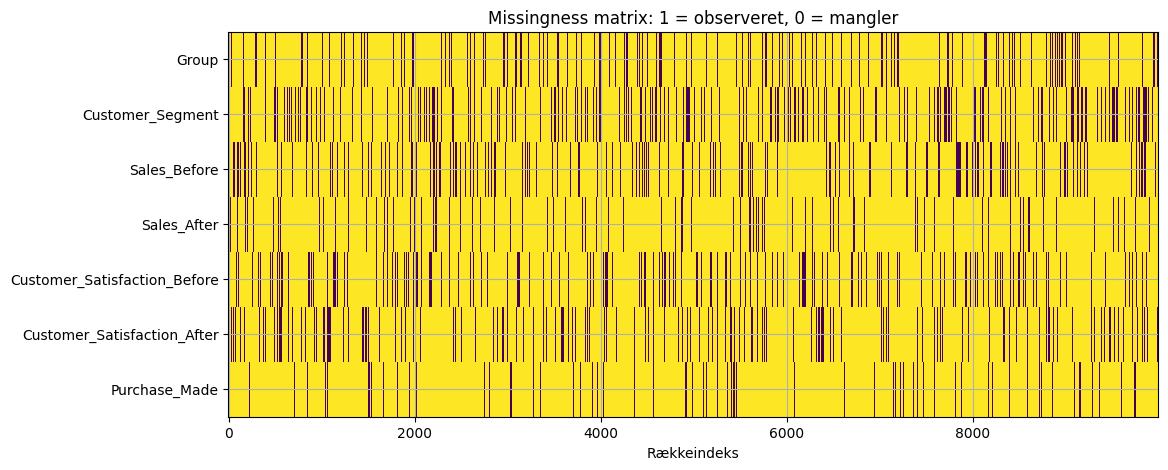

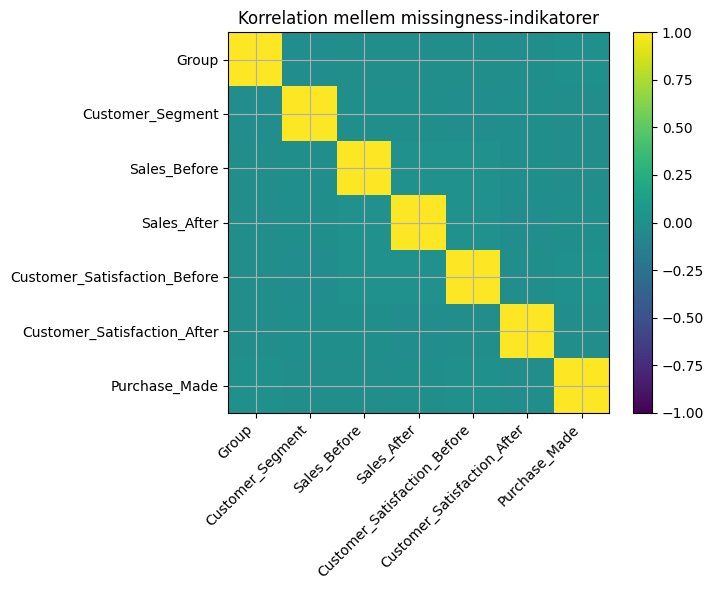

,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
Group,1.000,-0.017,-0.008,-0.012,-0.008,-0.012,0.001
Customer_Segment,-0.017,1.000,-0.000,-0.004,-0.017,-0.000,-0.011
Sales_Before,-0.008,-0.000,1.000,0.013,0.012,-0.003,-0.009
Sales_After,-0.012,-0.004,0.013,1.000,0.013,-0.018,-0.001
Customer_Satisfaction_Before,-0.008,-0.017,0.012,0.013,1.000,-0.011,0.007
Customer_Satisfaction_After,-0.012,-0.000,-0.003,-0.018,-0.011,1.000,-0.009
Purchase_Made,0.001,-0.011,-0.009,-0.001,0.007,-0.009,1.000


In [4]:
# Missingness matrix: mørke felter = værdi findes, lyse felter = mangler
missing_matrix = sales_nan.notna().astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(missing_matrix.T, aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(sales_nan.columns)))
ax.set_yticklabels(sales_nan.columns)
ax.set_xlabel("Rækkeindeks")
ax.set_title("Missingness matrix: 1 = observeret, 0 = mangler")
plt.show()
plt.close("all")

# Korrelation mellem indikatorer for manglende værdier
missing_indicator = sales_nan.isna().astype(int)
missing_corr = missing_indicator.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(missing_corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(missing_corr.columns)))
ax.set_xticklabels(missing_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(missing_corr.columns)))
ax.set_yticklabels(missing_corr.columns)
ax.set_title("Korrelation mellem missingness-indikatorer")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
plt.close("all")

display(missing_corr.round(3))

## 1.3 Kvantitativ vurdering af missingness: kan mangler forudsiges?

**Metodeidé:** For hver kolonne med manglende værdier oprettes en binær targetvariabel: `1 = værdien mangler`, `0 = værdien findes`. Derefter trænes en lille classifier på de øvrige kolonner. Hvis modellen kan forudsige missingness markant bedre end tilfældigt, tyder det på, at manglen afhænger af observerede variable og dermed har et MAR-præg.

**Fortolkning af AUC:**

- ca. 0.50: missingness ligner tilfældig variation i forhold til de observerede variable.
- 0.60–0.70: svag/moderat struktur.
- over 0.70: tydelig struktur og sandsynligt MAR.

Dette er ikke et matematisk bevis for MCAR/MAR/MNAR, men et praktisk diagnostisk værktøj.

In [5]:
def make_ohe():
    # Kompatibilitet med forskellige scikit-learn-versioner
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def missingness_auc_table(df, min_missing=20):
    results = []
    for target_col in df.columns:
        y = df[target_col].isna().astype(int)
        if y.sum() < min_missing or y.nunique() < 2:
            continue
        X = df.drop(columns=[target_col]).copy()
        num_cols = X.select_dtypes(include="number").columns.tolist()
        cat_cols = X.select_dtypes(exclude="number").columns.tolist()
        pre = ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", make_ohe())
            ]), cat_cols)
        ])
        model = Pipeline([
            ("pre", pre),
            ("clf", RandomForestClassifier(n_estimators=40, random_state=RANDOM_STATE, min_samples_leaf=10, n_jobs=1))
        ])
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
        )
        model.fit(X_train, y_train)
        prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, prob)
        results.append({
            "kolonne": target_col,
            "missing_count": int(y.sum()),
            "missing_pct": round(y.mean() * 100, 2),
            "AUC_missingness_classifier": round(auc, 3),
            "foreløbig_tolkning": "MCAR-lignende" if auc < 0.60 else ("svag/moderat MAR-struktur" if auc < 0.70 else "tydelig MAR-struktur")
        })
    return pd.DataFrame(results).sort_values("AUC_missingness_classifier", ascending=False)

missingness_eval = missingness_auc_table(sales_nan)
display(missingness_eval)

print("Samlet vurdering:")
if len(missingness_eval) > 0 and missingness_eval["AUC_missingness_classifier"].max() >= 0.60:
    print("Mindst én missingness-indikator kan forudsiges bedre end tilfældigt. Det peger på, at datamanglen ikke er ren MCAR, men har et MAR-præg.")
else:
    print("Missingness kan ikke forudsiges markant bedre end tilfældigt. Det peger på MCAR-lignende mangler i dette datasæt.")
print("MNAR kan ikke afvises endeligt uden viden om den dataindsamlingsproces, der har skabt NaN-værdierne.")

,kolonne,missing_count,missing_pct,AUC_missingness_classifier,foreløbig_tolkning
4,Customer_Satisfaction_Before,1670,16.70,0.510,MCAR-lignende
5,Customer_Satisfaction_After,1640,16.40,0.509,MCAR-lignende
3,Sales_After,767,7.67,0.503,MCAR-lignende
2,Sales_Before,1522,15.22,0.501,MCAR-lignende
6,Purchase_Made,805,8.05,0.501,MCAR-lignende
0,Group,1401,14.01,0.498,MCAR-lignende
1,Customer_Segment,1966,19.66,0.484,MCAR-lignende


Samlet vurdering:
Missingness kan ikke forudsiges markant bedre end tilfældigt. Det peger på MCAR-lignende mangler i dette datasæt.
MNAR kan ikke afvises endeligt uden viden om den dataindsamlingsproces, der har skabt NaN-værdierne.


## 1.4 Fordelinger før imputering

**Overvejelse:** Imputering kan forvrænge fordelinger. Derfor visualiseres de numeriske variable før imputering. Hvis en metode fx indsætter medianen mange gange, kan det skabe en kunstig top omkring medianen. Det er især relevant ved variable med mange manglende værdier.

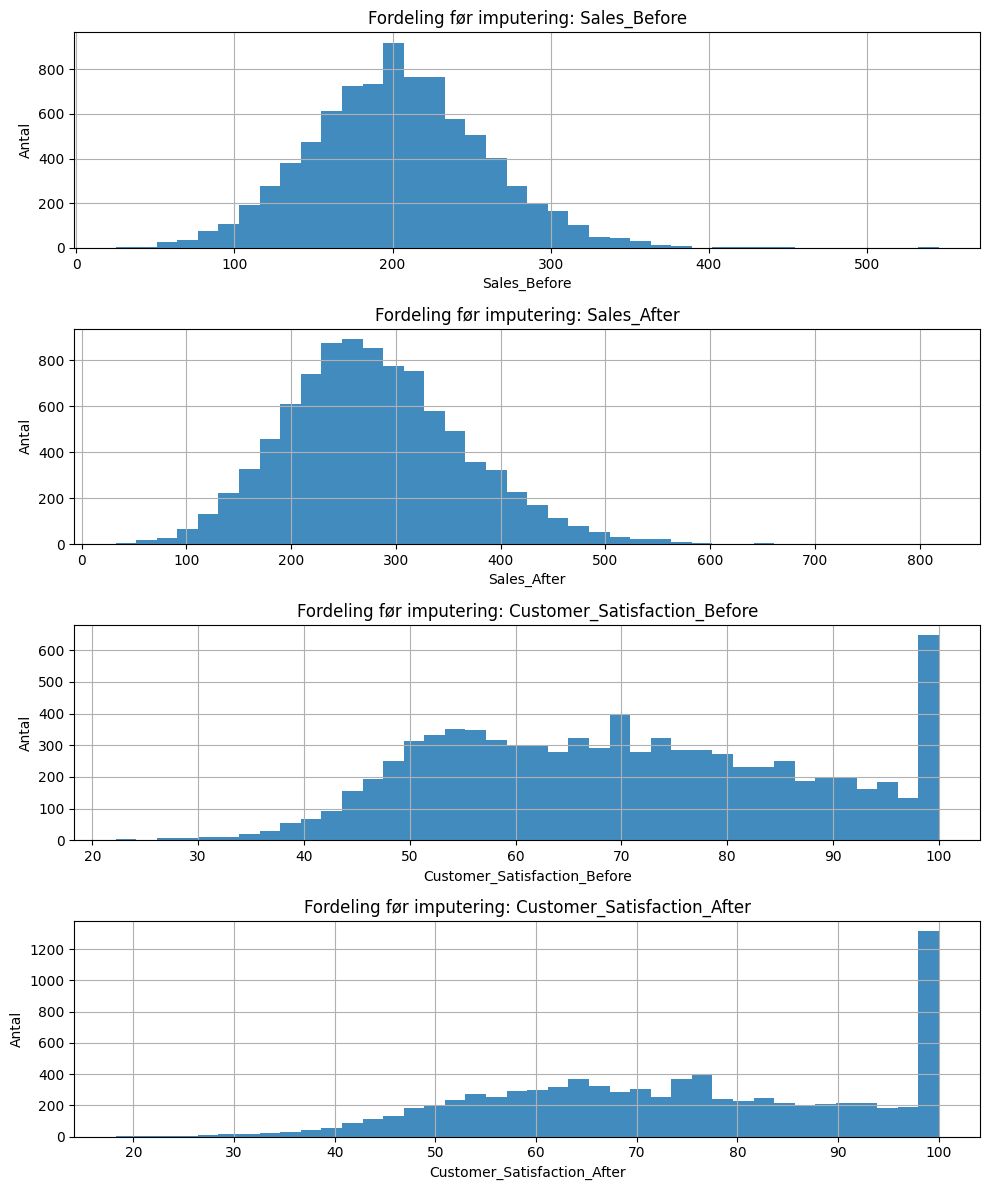


Group


,count
Group,
Control,4300
Treatment,4299
NaN,1401



Customer_Segment


,count
Customer_Segment,
Low Value,2699
Medium Value,2697
High Value,2638
NaN,1966



Purchase_Made


,count
Purchase_Made,
Yes,4667
No,4528
NaN,805


In [6]:
num_cols_sales = sales_nan.select_dtypes(include="number").columns.tolist()
cat_cols_sales = sales_nan.select_dtypes(exclude="number").columns.tolist()

fig, axes = plt.subplots(len(num_cols_sales), 1, figsize=(10, 3 * len(num_cols_sales)))
if len(num_cols_sales) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols_sales):
    ax.hist(sales_nan[col].dropna(), bins=40, alpha=0.85)
    ax.set_title(f"Fordeling før imputering: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Antal")
plt.tight_layout()
plt.show()
plt.close("all")

# Kategoriske fordelinger
for col in cat_cols_sales:
    print(f"\n{col}")
    display(sales_nan[col].value_counts(dropna=False).to_frame("count"))

## 1.5 Implementering af imputeringsmetoder

Der implementeres tre metoder:

1. **Simple median/mode**: hurtig og robust baseline.
2. **Random sampling**: bevarer i højere grad kolonnefordelingen, fordi værdier samples fra observerede værdier i samme variabel.
3. **Iterativ/regressionsbaseret imputering for numeriske variable**: estimerer manglende numeriske værdier ud fra de øvrige numeriske variable. Kategoriske variable håndteres med mode.

**Overvejelse:** Hvis datamanglen er MCAR-lignende, kan simple metoder være nok. Hvis den har MAR-præg, kan regressionsbaserede eller iterative metoder være mere relevante, fordi de bruger information fra andre variable.

In [7]:
# Hjælpefunktioner til imputering

def simple_median_mode_impute(df):
    out = df.copy()
    num_cols = out.select_dtypes(include="number").columns.tolist()
    cat_cols = out.select_dtypes(exclude="number").columns.tolist()
    for col in num_cols:
        out[col] = out[col].fillna(out[col].median())
    for col in cat_cols:
        out[col] = out[col].fillna(out[col].mode(dropna=True)[0])
    return out


def random_sampling_impute(df, random_state=42):
    local_rng = np.random.default_rng(random_state)
    out = df.copy()
    for col in out.columns:
        mask = out[col].isna()
        observed = out.loc[~mask, col].dropna().to_numpy()
        if mask.sum() > 0 and len(observed) > 0:
            out.loc[mask, col] = local_rng.choice(observed, size=mask.sum(), replace=True)
    return out


def iterative_numeric_mode_categorical_impute(df, max_iter=10):
    out = df.copy()
    num_cols = out.select_dtypes(include="number").columns.tolist()
    cat_cols = out.select_dtypes(exclude="number").columns.tolist()
    if num_cols:
        imp = IterativeImputer(max_iter=max_iter, random_state=RANDOM_STATE, initial_strategy="median")
        out[num_cols] = imp.fit_transform(out[num_cols])
    for col in cat_cols:
        out[col] = out[col].fillna(out[col].mode(dropna=True)[0])
    return out

sales_simple = simple_median_mode_impute(sales_nan)
sales_sampling = random_sampling_impute(sales_nan, random_state=RANDOM_STATE)
sales_iterative = iterative_numeric_mode_categorical_impute(sales_nan, max_iter=10)

print("Manglende værdier efter imputering:")
summary_after = pd.DataFrame({
    "Simple median/mode": sales_simple.isna().sum(),
    "Random sampling": sales_sampling.isna().sum(),
    "Iterativ numeric + mode cat": sales_iterative.isna().sum()
})
display(summary_after)

Manglende værdier efter imputering:


,Simple median/mode,Random sampling,Iterativ numeric + mode cat
Group,0,0,0
Customer_Segment,0,0,0
Sales_Before,0,0,0
Sales_After,0,0,0
Customer_Satisfaction_Before,0,0,0
Customer_Satisfaction_After,0,0,0
Purchase_Made,0,0,0


## 1.6 Sammenligning mod referencefil uden NaNs

**Overvejelse:** Fordi vi har en version uden NaNs, kan vi evaluere imputeringsfejl på de celler, der faktisk var fjernet i NaN-versionen. Dette giver en direkte kvalitetsmåling:

- Numeriske kolonner evalueres med **MAE** og **RMSE**.
- Kategoriske kolonner evalueres med **accuracy** på de tidligere manglende celler.

Referencefilen bruges kun til evaluering, ikke til at “hjælpe” imputeringen.

In [8]:
# Sørg for samme kolonner og rækkeorden
assert list(sales_nan.columns) == list(sales_full.columns), "Kolonnerne matcher ikke mellem NaN- og referencefil."
assert len(sales_nan) == len(sales_full), "Antal rækker matcher ikke mellem NaN- og referencefil."

imputed_versions = {
    "Simple median/mode": sales_simple,
    "Random sampling": sales_sampling,
    "Iterativ numeric + mode cat": sales_iterative
}

quality_rows = []
for method_name, df_imp in imputed_versions.items():
    for col in sales_nan.columns:
        mask = sales_nan[col].isna()
        if mask.sum() == 0:
            continue
        if pd.api.types.is_numeric_dtype(sales_full[col]):
            err = df_imp.loc[mask, col].astype(float) - sales_full.loc[mask, col].astype(float)
            quality_rows.append({
                "metode": method_name,
                "kolonne": col,
                "type": "numerisk",
                "n_eval": int(mask.sum()),
                "MAE": float(np.mean(np.abs(err))),
                "RMSE": float(np.sqrt(np.mean(err ** 2))),
                "Accuracy": np.nan
            })
        else:
            acc = (df_imp.loc[mask, col].astype(str).values == sales_full.loc[mask, col].astype(str).values).mean()
            quality_rows.append({
                "metode": method_name,
                "kolonne": col,
                "type": "kategorisk",
                "n_eval": int(mask.sum()),
                "MAE": np.nan,
                "RMSE": np.nan,
                "Accuracy": float(acc)
            })

imputation_quality = pd.DataFrame(quality_rows)
display(imputation_quality.round(4))

# Samlet overblik pr. metode
method_summary = imputation_quality.groupby("metode").agg(
    mean_MAE=("MAE", "mean"),
    mean_RMSE=("RMSE", "mean"),
    mean_categorical_accuracy=("Accuracy", "mean")
).reset_index()
display(method_summary.round(4))

,metode,kolonne,type,n_eval,MAE,RMSE,Accuracy
0,Simple median/mode,Group,kategorisk,1401,NaN,NaN,0.5089
1,Simple median/mode,Customer_Segment,kategorisk,1966,NaN,NaN,0.3332
2,Simple median/mode,Sales_Before,numerisk,1522,44.4820,56.3122,NaN
3,Simple median/mode,Sales_After,numerisk,767,65.0119,83.3052,NaN
4,Simple median/mode,Customer_Satisfaction_Before,numerisk,1670,14.0939,16.7968,NaN
5,Simple median/mode,Customer_Satisfaction_After,numerisk,1640,15.8426,18.4722,NaN
6,Simple median/mode,Purchase_Made,kategorisk,805,NaN,NaN,0.5081
7,Random sampling,Group,kategorisk,1401,NaN,NaN,0.4946
8,Random sampling,Customer_Segment,kategorisk,1966,NaN,NaN,0.3204
9,Random sampling,Sales_Before,numerisk,1522,62.6968,77.9601,NaN


,metode,mean_MAE,mean_RMSE,mean_categorical_accuracy
0,Iterativ numeric + mode cat,20.3661,25.0250,0.4501
1,Random sampling,49.5389,61.9200,0.4290
2,Simple median/mode,34.8576,43.7216,0.4501


## 1.7 Visualisering før og efter imputering

**Overvejelse:** En metode kan give god modelperformance, men stadig forvrænge datastrukturen. Derfor sammenlignes numeriske fordelinger visuelt før og efter imputering. Random sampling forventes ofte at bevare fordelingen bedre end ren medianimputering, mens Iterativ imputering kan bevare relationer mellem numeriske variable.

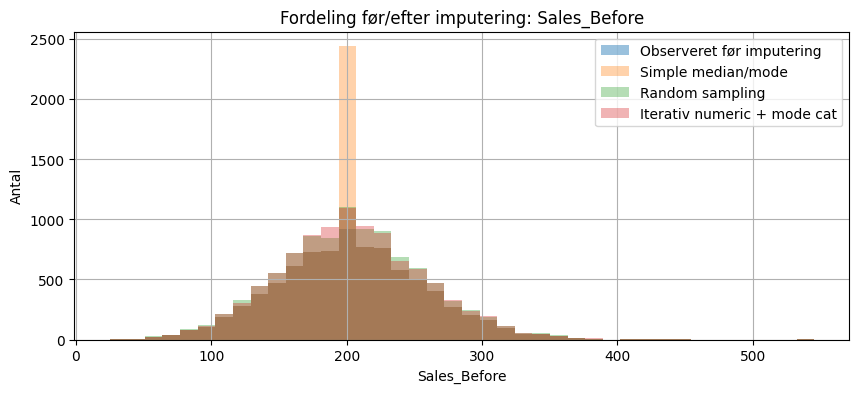

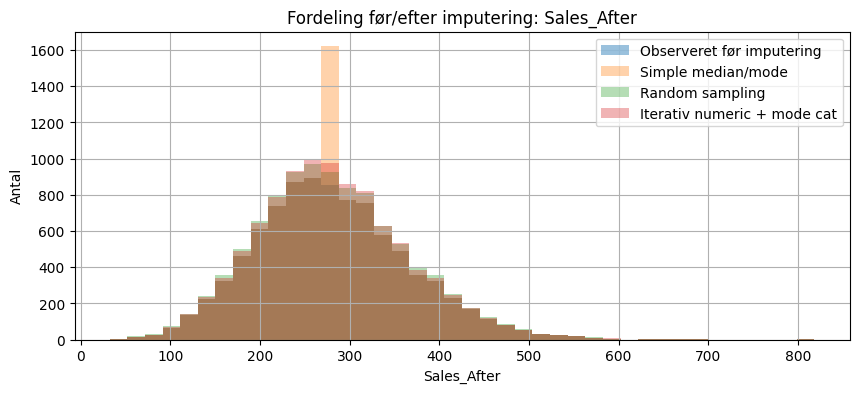

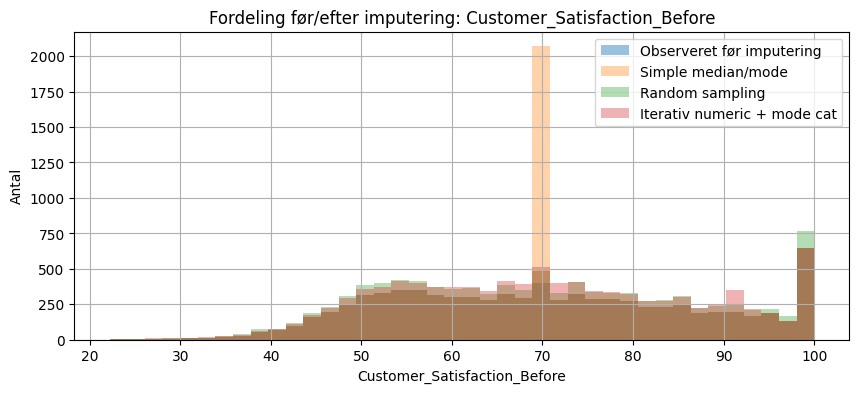

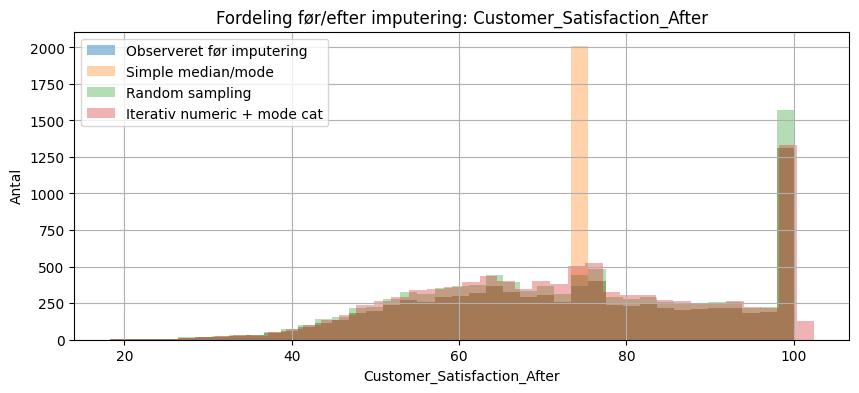

In [9]:
for col in num_cols_sales:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(sales_nan[col].dropna(), bins=40, alpha=0.45, label="Observeret før imputering")
    ax.hist(sales_simple[col], bins=40, alpha=0.35, label="Simple median/mode")
    ax.hist(sales_sampling[col], bins=40, alpha=0.35, label="Random sampling")
    ax.hist(sales_iterative[col], bins=40, alpha=0.35, label="Iterativ numeric + mode cat")
    ax.set_title(f"Fordeling før/efter imputering: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Antal")
    ax.legend()
    plt.show()
plt.close("all")

## 1.8 Classifier med og uden imputering

**Formål:** Opgaven beder om at sammenligne metoderne fx ved brug af en classifier med/uden imputering. Her bruges `Purchase_Made` som target.

**Sammenligningsdesign:**

- **Uden imputering / complete-case**: rækker med manglende features fjernes.
- **Med imputering**: alle rækker med kendt target kan bruges, fordi manglende features udfyldes.
- **Reference uden NaNs**: den komplette fil bruges som en ekstra øvre kontrolbaseline. Den bør ikke ses som realistisk tilgængelig i en rigtig NaN-opgave.

**Evalueringsmål:** Accuracy, precision, recall og F1. F1 er særligt nyttig, hvis klasserne ikke er helt balancerede.

In [10]:
def evaluate_classifier_with_pipeline(X_train, X_test, y_train, y_test, numeric_transformer, categorical_transformer, name):
    num_cols = X_train.select_dtypes(include="number").columns.tolist()
    cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()
    pre = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ])
    clf = Pipeline([
        ("pre", pre),
        ("model", RandomForestClassifier(n_estimators=60, random_state=RANDOM_STATE, min_samples_leaf=5, n_jobs=1))
    ])
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    return {
        "metode": name,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "accuracy": accuracy_score(y_test, pred),
        "precision_yes": precision_score(y_test, pred, pos_label="Yes", zero_division=0),
        "recall_yes": recall_score(y_test, pred, pos_label="Yes", zero_division=0),
        "f1_yes": f1_score(y_test, pred, pos_label="Yes", zero_division=0),
    }


def ohe_only_transformer():
    return make_ohe()

# Brug kun rækker hvor target findes i NaN-versionen.
target_col = "Purchase_Made"
feature_cols = [c for c in sales_nan.columns if c != target_col]
mask_target = sales_nan[target_col].notna()
X = sales_nan.loc[mask_target, feature_cols]
y = sales_nan.loc[mask_target, target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

results = []

# 1) Uden imputering: complete-case på train/test efter split
train_cc_mask = X_train.notna().all(axis=1)
test_cc_mask = X_test.notna().all(axis=1)
X_train_cc, y_train_cc = X_train.loc[train_cc_mask], y_train.loc[train_cc_mask]
X_test_cc, y_test_cc = X_test.loc[test_cc_mask], y_test.loc[test_cc_mask]

results.append(evaluate_classifier_with_pipeline(
    X_train_cc, X_test_cc, y_train_cc, y_test_cc,
    numeric_transformer="passthrough",
    categorical_transformer=ohe_only_transformer(),
    name="Uden imputering (complete-case)"
))

# 2) Simple median/mode
results.append(evaluate_classifier_with_pipeline(
    X_train, X_test, y_train, y_test,
    numeric_transformer=SimpleImputer(strategy="median"),
    categorical_transformer=Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", make_ohe())]),
    name="Simple median/mode"
))

# 3) Iterativ numerisk + mode kategorisk
results.append(evaluate_classifier_with_pipeline(
    X_train, X_test, y_train, y_test,
    numeric_transformer=IterativeImputer(max_iter=10, random_state=RANDOM_STATE, initial_strategy="median"),
    categorical_transformer=Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", make_ohe())]),
    name="Iterativ numeric + mode cat"
))

# 4) Random sampling: fit/sampling fra træningsdata, derefter classifier uden imputere i pipeline
X_train_sampling = random_sampling_impute(X_train, random_state=RANDOM_STATE)
# For test samples værdier fra træningsfordelingen for ikke at bruge testfordelingen til imputering
X_test_sampling = X_test.copy()
local_rng = np.random.default_rng(RANDOM_STATE)
for col in X_test_sampling.columns:
    mask = X_test_sampling[col].isna()
    observed_train = X_train[col].dropna().to_numpy()
    if mask.sum() > 0 and len(observed_train) > 0:
        X_test_sampling.loc[mask, col] = local_rng.choice(observed_train, size=mask.sum(), replace=True)

results.append(evaluate_classifier_with_pipeline(
    X_train_sampling, X_test_sampling, y_train, y_test,
    numeric_transformer="passthrough",
    categorical_transformer=ohe_only_transformer(),
    name="Random sampling"
))

# 5) Reference uden NaNs på samme indeks som rækkerne med kendt target i NaN-filen
X_ref = sales_full.loc[mask_target, feature_cols]
y_ref = sales_full.loc[mask_target, target_col]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_ref, y_ref, test_size=0.25, random_state=RANDOM_STATE, stratify=y_ref
)
results.append(evaluate_classifier_with_pipeline(
    Xr_train, Xr_test, yr_train, yr_test,
    numeric_transformer="passthrough",
    categorical_transformer=ohe_only_transformer(),
    name="Referencefil uden NaNs"
))

classifier_results = pd.DataFrame(results).sort_values("f1_yes", ascending=False)
display(classifier_results.round(4))

,metode,n_train,n_test,accuracy,precision_yes,recall_yes,f1_yes
2,Iterativ numeric + mode cat,6896,2299,0.5294,0.5341,0.5698,0.5514
4,Referencefil uden NaNs,6896,2299,0.5080,0.5146,0.5424,0.5282
0,Uden imputering (complete-case),2567,845,0.5349,0.5383,0.5142,0.5259
1,Simple median/mode,6896,2299,0.5067,0.5136,0.5356,0.5243
3,Random sampling,6896,2299,0.4985,0.5057,0.5278,0.5166


### Delkonklusion for Del 1

- Manglende værdier findes i både numeriske og kategoriske variable, og andelen varierer mellem kolonner.
- Missingness-vurderingen bør ikke kun baseres på én visualisering. Kombinationen af missingness matrix, korrelationsmatrix og missingness-classifier giver et mere nuanceret grundlag.
- Hvis AUC-værdierne i missingness-classifieren ligger tæt på 0.5, ligner mønsteret MCAR. Hvis flere AUC-værdier ligger klart over 0.6, tyder det på MAR, fordi manglende værdier kan forklares ud fra observerede variable.
- Median/mode er en stærk baseline, men kan forvrænge numeriske fordelinger ved at samle mange observationer omkring medianen.
- Random sampling kan bevare marginalfordelingen bedre, men bruger ikke relationer mellem variable.
- Regressions-/iterativ imputering kan være mere passende ved MAR-lignende mønstre, fordi metoden bruger lighed mellem observationer.
- Classifier-resultatet viser den praktiske effekt: imputering gør det muligt at bruge flere rækker end complete-case og kan derfor forbedre modelgrundlaget, men kvaliteten afhænger af imputeringsmetoden.

## 1.9 Strukturering i relationel SQLite-database

**Overvejelse:** En flad CSV-fil gentager kunde- og eksperimentoplysninger i samme tabel. I en relationel struktur kan data opdeles efter emne og forbindes med nøgler. Det reducerer redundans og gør det lettere at lave forespørgsler.

Her oprettes én SQLite-database med mindst to relaterede tabeller:

1. `customers`: én række pr. kunde/observation med `customer_id` som primærnøgle.
2. `sales_experiment`: salgs- og tilfredshedsmålinger med `customer_id` som fremmednøgle.

Da datasættet ikke har et naturligt kunde-id, oprettes `customer_id` ud fra rækkeindekset.

In [11]:
# Brug den iterative imputationsversion som analyseret/komplet datasæt til databaseeksemplet
sales_db_df = sales_iterative.copy().reset_index().rename(columns={"index": "customer_id"})
sales_db_df["customer_id"] = sales_db_df["customer_id"].astype(int)

# SQLite-database oprettes i samme mappe som notebooken
out_dir = Path.cwd() if Path.cwd().exists() else Path("/mnt/data")
if not (out_dir / "Sales_with_NaNs_v1.3.csv").exists() and Path("/mnt/data").exists():
    out_dir = Path("/mnt/data")

db_path = out_dir / "sales_relational.sqlite"
if db_path.exists():
    db_path.unlink()

conn = sqlite3.connect(db_path)
conn.execute("PRAGMA foreign_keys = ON;")
cur = conn.cursor()

cur.execute("""
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    customer_segment TEXT NOT NULL
);
""")

cur.execute("""
CREATE TABLE sales_experiment (
    record_id INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_id INTEGER NOT NULL,
    group_label TEXT NOT NULL,
    sales_before REAL,
    sales_after REAL,
    satisfaction_before REAL,
    satisfaction_after REAL,
    purchase_made TEXT,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);
""")

customers = sales_db_df[["customer_id", "Customer_Segment"]].rename(columns={"Customer_Segment": "customer_segment"})
customers.to_sql("customers", conn, if_exists="append", index=False)

experiment = sales_db_df[[
    "customer_id", "Group", "Sales_Before", "Sales_After",
    "Customer_Satisfaction_Before", "Customer_Satisfaction_After", "Purchase_Made"
]].rename(columns={
    "Group": "group_label",
    "Sales_Before": "sales_before",
    "Sales_After": "sales_after",
    "Customer_Satisfaction_Before": "satisfaction_before",
    "Customer_Satisfaction_After": "satisfaction_after",
    "Purchase_Made": "purchase_made"
})
experiment.to_sql("sales_experiment", conn, if_exists="append", index=False)

conn.commit()

# Kontrol af skemaer
schema_tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
display(schema_tables)

for table in ["customers", "sales_experiment"]:
    print(f"\nSkema for {table}")
    display(pd.read_sql_query(f"PRAGMA table_info({table});", conn))

print("Foreign keys i sales_experiment:")
display(pd.read_sql_query("PRAGMA foreign_key_list(sales_experiment);", conn))

# Eksempel på relationel forespørgsel med JOIN
query = """
SELECT
    c.customer_segment,
    e.group_label,
    COUNT(*) AS n,
    AVG(e.sales_before) AS avg_sales_before,
    AVG(e.sales_after) AS avg_sales_after,
    AVG(e.satisfaction_after) AS avg_satisfaction_after,
    SUM(CASE WHEN e.purchase_made = 'Yes' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS purchase_rate
FROM sales_experiment e
JOIN customers c ON e.customer_id = c.customer_id
GROUP BY c.customer_segment, e.group_label
ORDER BY c.customer_segment, e.group_label;
"""
join_summary = pd.read_sql_query(query, conn)
display(join_summary.round(3))

conn.close()
print(f"Database gemt som: {db_path}")

,name
0,customers
1,sales_experiment
2,sqlite_sequence



Skema for customers


,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,INTEGER,0,None,1
1,1,customer_segment,TEXT,1,None,0



Skema for sales_experiment


,cid,name,type,notnull,dflt_value,pk
0,0,record_id,INTEGER,0,None,1
1,1,customer_id,INTEGER,1,None,0
2,2,group_label,TEXT,1,None,0
3,3,sales_before,REAL,0,None,0
4,4,sales_after,REAL,0,None,0
5,5,satisfaction_before,REAL,0,None,0
6,6,satisfaction_after,REAL,0,None,0
7,7,purchase_made,TEXT,0,None,0


Foreign keys i sales_experiment:


,id,seq,table,from,to,on_update,on_delete,match
0,0,0,customers,customer_id,customer_id,NO ACTION,NO ACTION,NONE


,customer_segment,group_label,n,avg_sales_before,avg_sales_after,avg_satisfaction_after,purchase_rate
0,High Value,Control,1518,220.323,278.131,89.286,0.542
1,High Value,Treatment,1120,229.138,347.826,89.517,0.553
2,Low Value,Control,2638,189.902,239.923,64.899,0.560
3,Low Value,Treatment,2027,195.497,297.011,64.552,0.554
4,Medium Value,Control,1545,201.311,254.998,74.787,0.522
5,Medium Value,Treatment,1152,208.073,315.714,74.485,0.543


Database gemt som: c:\Users\Sebastian\Documents\Visuel studio code\AI\Alle-Opgaver-fra-Git\AI-og-Data-Miniprojekt1\sales_relational.sqlite


# Del 2 – Støj i tidsseriedata og vinduesmetoden

## 2.1 Indlæsning og klargøring af tidsserier

**Overvejelse:** Train- og testfilerne kombineres for at få hele tidsforløbet. Dato konverteres til `datetime`, og data sorteres kronologisk. Dette er nødvendigt, fordi tidsserieanalyse afhænger af korrekt rækkefølge.

In [12]:
climate_train = pd.read_csv(climate_train_path)
climate_test = pd.read_csv(climate_test_path)

climate = pd.concat([climate_train, climate_test], ignore_index=True)
climate["date"] = pd.to_datetime(climate["date"])
climate = climate.sort_values("date").reset_index(drop=True)

numeric_cols_climate = climate.select_dtypes(include="number").columns.tolist()

print("Tidsperiode:", climate["date"].min().date(), "til", climate["date"].max().date())
print("Antal observationer:", len(climate))
print("Numeriske tidsserier:", numeric_cols_climate)
display(climate.head())
display(climate.describe().T.round(3))

Tidsperiode: 2013-01-01 til 2017-04-24
Antal observationer: 1576
Numeriske tidsserier: ['meantemp', 'humidity', 'wind_speed', 'meanpressure']


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


,count,mean,min,25%,50%,75%,max,std
date,1576,2015-02-27 10:15:50.253807104,2013-01-01 00:00:00,2014-01-29 18:00:00,2015-02-27 12:00:00,2016-03-27 06:00:00,2017-04-24 00:00:00,NaN
meantemp,1576.0,25.221918,6.0,18.5,27.166667,31.142857,38.714286,7.345014
humidity,1576.0,60.445229,13.428571,49.75,62.440476,72.125,100.0,16.979994
wind_speed,1576.0,6.899262,0.0,3.7,6.363571,9.2625,42.22,4.510725
meanpressure,1576.0,1010.593178,-3.041667,1001.875,1009.055556,1015.2,7679.333333,175.242704


## 2.2 Første visualisering af rå tidsserier

**Overvejelse:** Rå plots bruges til at vurdere:

- trend over tid,
- sæsonmønstre,
- kortsigtede udsving,
- ekstreme værdier, der kan skyldes datafejl eller sensorfejl.

Hvis enkelte ekstreme fejl dominerer skalaen, kan støjvurderingen blive misvisende. Derfor undersøges outliers før den endelige udglatning.

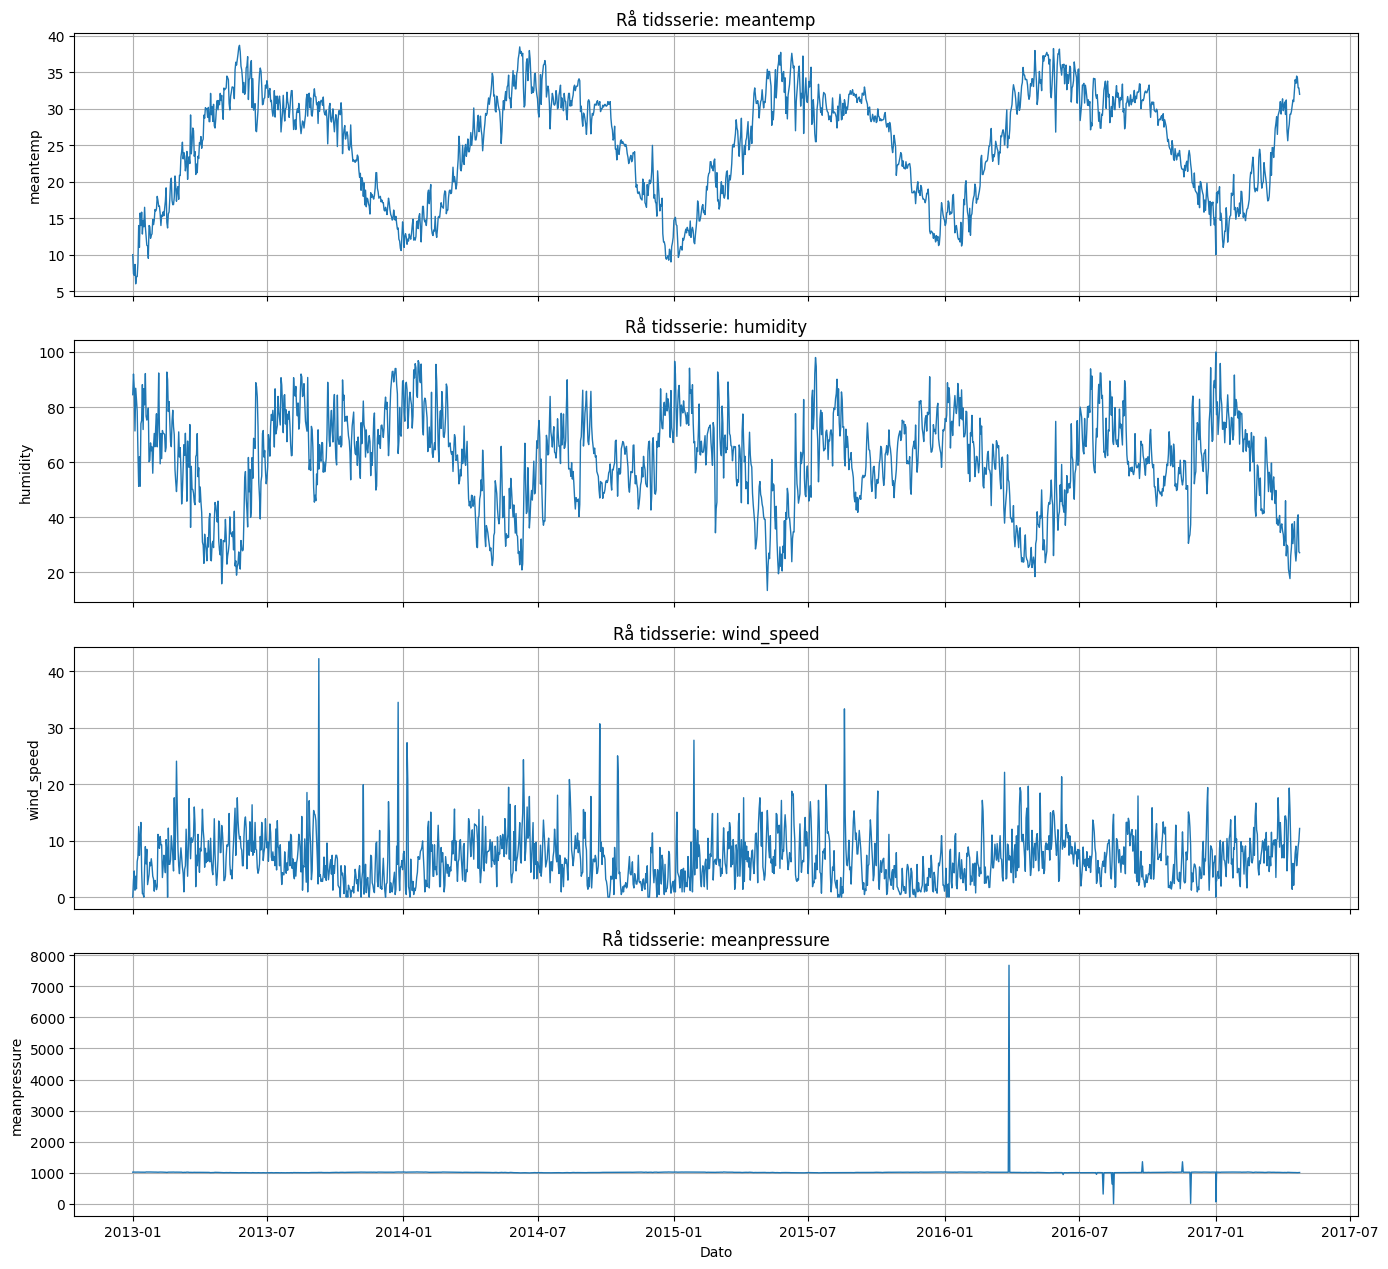

In [13]:
fig, axes = plt.subplots(len(numeric_cols_climate), 1, figsize=(14, 3.2 * len(numeric_cols_climate)), sharex=True)
if len(numeric_cols_climate) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols_climate):
    ax.plot(climate["date"], climate[col], linewidth=1)
    ax.set_title(f"Rå tidsserie: {col}")
    ax.set_ylabel(col)
axes[-1].set_xlabel("Dato")
plt.tight_layout()
plt.show()
plt.close("all")

## 2.3 Datafejl/outliers før støjvurdering

**Overvejelse:** Støj er ikke det samme som åbenlyse datafejl. Et glidende gennemsnit kan reducere tilfældige udsving, men ekstreme fejl kan trække gennemsnittet kraftigt. Derfor markeres stærke outliers i `meanpressure` som manglende og erstattes med tidsinterpolation, før støjgraden estimeres.

Dette er ikke en egentlig imputeringsanalyse som i Del 1, men en nødvendig oprensning for at undgå, at få ekstreme punkter bestemmer hele vurderingen af støj.

Antal stærke outliers i meanpressure: 8


,date,meanpressure
1182,2016-03-28,7679.333333
1309,2016-08-02,310.437500
1321,2016-08-14,633.900000
1323,2016-08-16,-3.041667
1362,2016-09-24,1352.615385
1416,2016-11-17,1350.296296
1427,2016-11-28,12.045455
1462,2017-01-01,59.000000


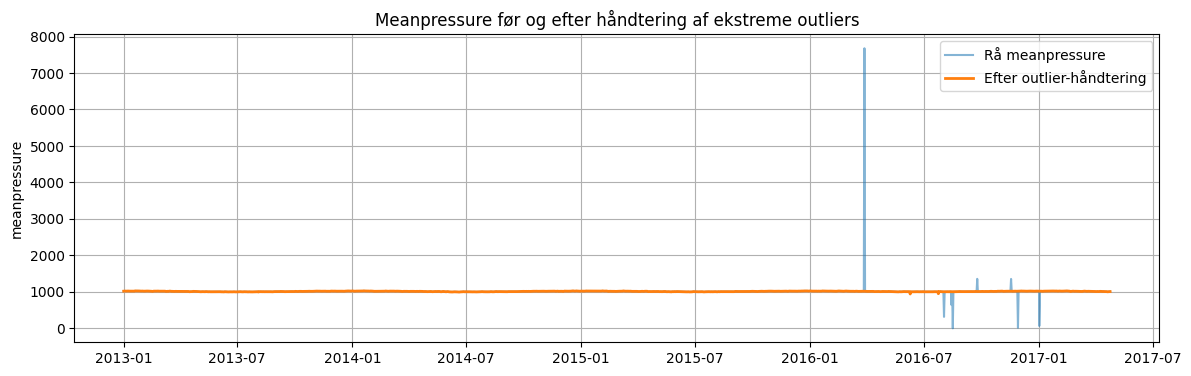

In [14]:
def robust_outlier_mask(series, threshold=8.0):
    med = series.median()
    mad = np.median(np.abs(series - med))
    if mad == 0:
        return pd.Series(False, index=series.index)
    robust_z = 0.6745 * (series - med) / mad
    return robust_z.abs() > threshold

climate_clean = climate.copy()
pressure_mask = robust_outlier_mask(climate_clean["meanpressure"], threshold=8.0)

print("Antal stærke outliers i meanpressure:", int(pressure_mask.sum()))
display(climate_clean.loc[pressure_mask, ["date", "meanpressure"]])

climate_clean.loc[pressure_mask, "meanpressure"] = np.nan
climate_clean["meanpressure"] = climate_clean["meanpressure"].interpolate(method="linear", limit_direction="both")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(climate["date"], climate["meanpressure"], label="Rå meanpressure", alpha=0.55)
ax.plot(climate_clean["date"], climate_clean["meanpressure"], label="Efter outlier-håndtering", linewidth=2)
ax.set_title("Meanpressure før og efter håndtering af ekstreme outliers")
ax.set_ylabel("meanpressure")
ax.legend()
plt.show()
plt.close("all")

## 2.4 Vurdering af støjgrad gennem visualisering og residualer

**Metode:** For hver tidsserie beregnes et 7-dages glidende gennemsnit som trendestimat. Residualen defineres som:

\[
\text{støj}_t = x_t - \text{trend}_t
\]

Derefter beregnes en simpel støjratio:

\[
\text{noise ratio} = \frac{\sigma(\text{residual})}{\sigma(x)}
\]

**Fortolkning:** Jo større ratio, desto større del af variationen ligger i kortsigtede udsving omkring trenden. Dette er en praktisk, ikke-absolut støjmåling, og den skal fortolkes sammen med visualiseringerne.

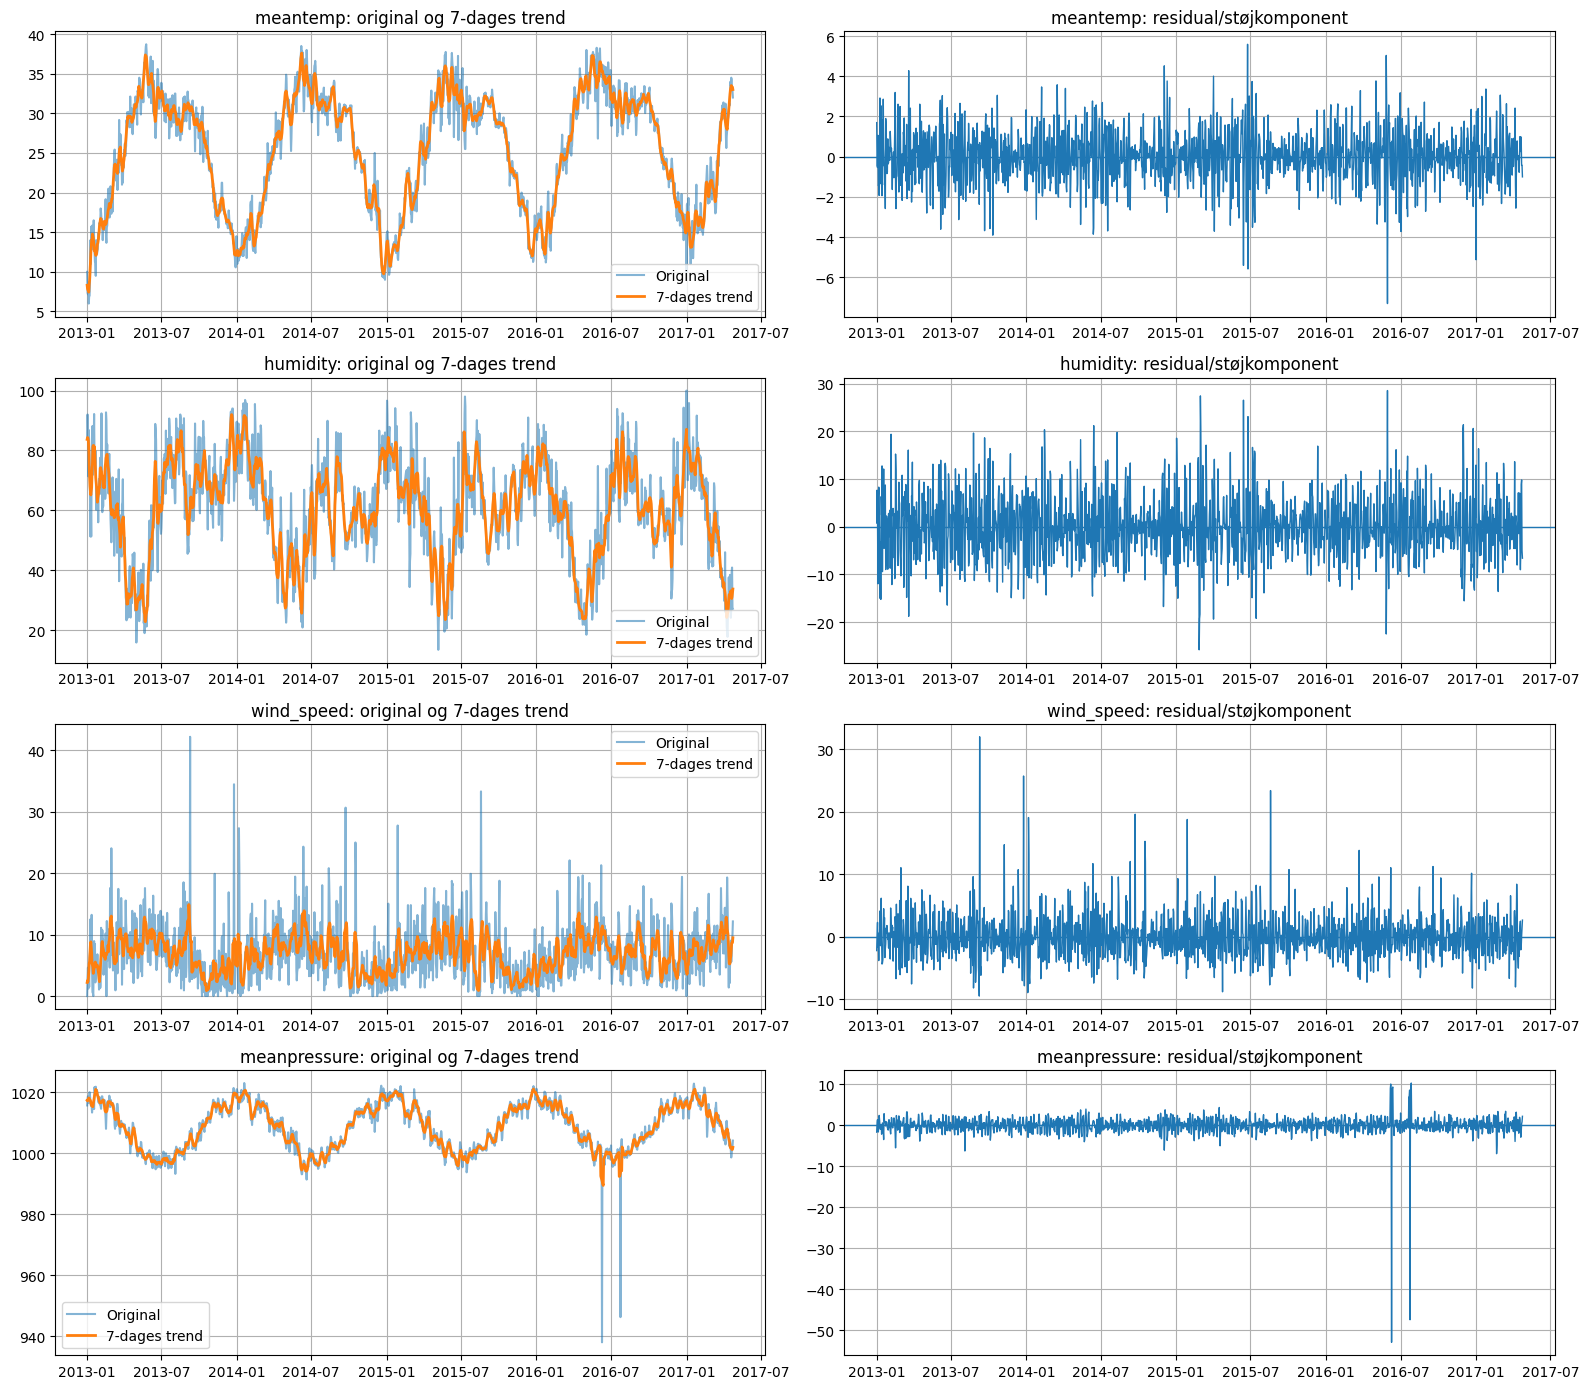

,tidsserie,std_original,std_residual_7d,noise_ratio,vurderet_støjgrad
0,meantemp,7.3450,1.2923,0.1759,moderat
1,humidity,16.9800,6.5347,0.3848,høj
2,wind_speed,4.5107,3.4895,0.7736,høj
3,meanpressure,7.7679,2.4077,0.3099,høj


In [15]:
noise_window = 7
noise_rows = []

fig, axes = plt.subplots(len(numeric_cols_climate), 2, figsize=(16, 3.5 * len(numeric_cols_climate)), sharex=False)
if len(numeric_cols_climate) == 1:
    axes = np.array([axes])

for i, col in enumerate(numeric_cols_climate):
    s = climate_clean[col]
    trend = s.rolling(window=noise_window, center=True, min_periods=1).mean()
    residual = s - trend
    ratio = residual.std() / s.std()
    label = "lav" if ratio < 0.15 else ("moderat" if ratio < 0.30 else "høj")
    noise_rows.append({
        "tidsserie": col,
        "std_original": s.std(),
        "std_residual_7d": residual.std(),
        "noise_ratio": ratio,
        "vurderet_støjgrad": label
    })
    axes[i, 0].plot(climate_clean["date"], s, label="Original", alpha=0.55)
    axes[i, 0].plot(climate_clean["date"], trend, label="7-dages trend", linewidth=2)
    axes[i, 0].set_title(f"{col}: original og 7-dages trend")
    axes[i, 0].legend()
    axes[i, 1].plot(climate_clean["date"], residual, linewidth=1)
    axes[i, 1].axhline(0, linewidth=1)
    axes[i, 1].set_title(f"{col}: residual/støjkomponent")

plt.tight_layout()
plt.show()
plt.close("all")

noise_summary = pd.DataFrame(noise_rows)
display(noise_summary.round(4))

## 2.5 Præprocessering med vinduesmetoden

**Valg af vindue:** 7 dage. Datasættet har daglige observationer, og 7 dage svarer til en uge. Det reducerer dag-til-dag støj, men bevarer langsommere temperatur-, fugtigheds- og trykmønstre.

**Metode:**

\[
\tilde{x}_t = \frac{1}{M}\sum_{i=t-k}^{t+k}x_i
\]

hvor \(M=7\) for et 7-dages centreret vindue. I praksis bruges `rolling(window=7, center=True)`.

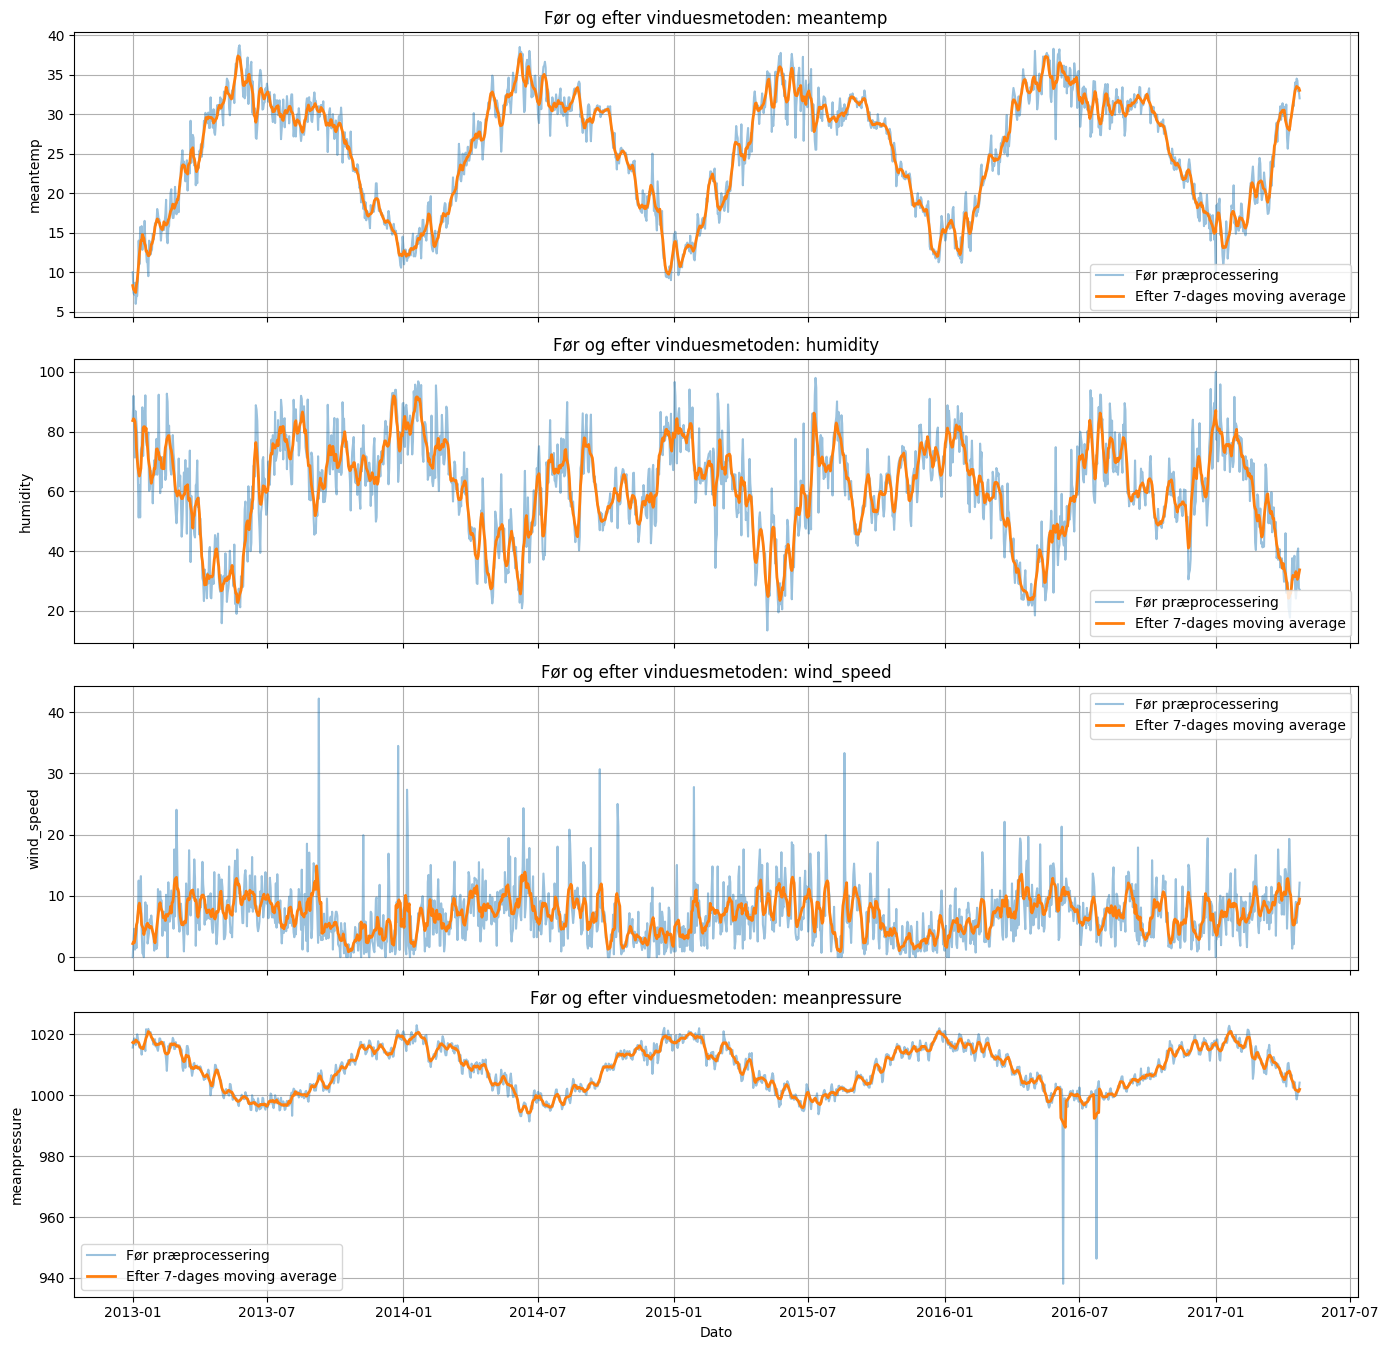

In [16]:
window = 7
climate_smoothed = climate_clean.copy()
for col in numeric_cols_climate:
    climate_smoothed[col] = climate_clean[col].rolling(window=window, center=True, min_periods=1).mean()

fig, axes = plt.subplots(len(numeric_cols_climate), 1, figsize=(14, 3.4 * len(numeric_cols_climate)), sharex=True)
if len(numeric_cols_climate) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols_climate):
    ax.plot(climate_clean["date"], climate_clean[col], label="Før præprocessering", alpha=0.45)
    ax.plot(climate_smoothed["date"], climate_smoothed[col], label="Efter 7-dages moving average", linewidth=2)
    ax.set_title(f"Før og efter vinduesmetoden: {col}")
    ax.set_ylabel(col)
    ax.legend()
axes[-1].set_xlabel("Dato")
plt.tight_layout()
plt.show()
plt.close("all")

## 2.6 Evaluering af vinduesmetoden

**Evalueringsidé:** Et glidende gennemsnit skal reducere kortsigtede udsving. Det kan måles ved at sammenligne standardafvigelsen af daglige ændringer før og efter præprocessering:

\[
\Delta x_t = x_t - x_{t-1}
\]

Hvis standardafvigelsen af \(\Delta x_t\) falder efter smoothing, er de hurtige udsving reduceret. Samtidig skal korrelationen mellem original og smoothed serie helst stadig være høj, så den overordnede struktur ikke fjernes.

In [17]:
eval_rows = []
for col in numeric_cols_climate:
    before_diff_std = climate_clean[col].diff().std()
    after_diff_std = climate_smoothed[col].diff().std()
    reduction = 1 - (after_diff_std / before_diff_std)
    corr = climate_clean[col].corr(climate_smoothed[col])
    eval_rows.append({
        "tidsserie": col,
        "std_daglig_ændring_før": before_diff_std,
        "std_daglig_ændring_efter": after_diff_std,
        "reduktion_i_kortsigtet_variation_pct": reduction * 100,
        "korrelation_original_smoothed": corr
    })

smoothing_eval = pd.DataFrame(eval_rows)
display(smoothing_eval.round(4))

,tidsserie,std_daglig_ændring_før,std_daglig_ændring_efter,reduktion_i_kortsigtet_variation_pct,korrelation_original_smoothed
0,meantemp,1.6788,0.4341,74.1431,0.9844
1,humidity,8.2045,1.9951,75.6832,0.9233
2,wind_speed,4.7683,0.8358,82.4726,0.6345
3,meanpressure,3.3719,0.6459,80.8459,0.9508


### Delkonklusion for Del 2

- De rå klimadata viser tydelige tidsseriemønstre og kortsigtede udsving.
- `meanpressure` indeholder enkelte ekstreme outliers, som først håndteres, fordi de ikke repræsenterer almindelig støj, men sandsynligvis datafejl.
- Støjgraden vurderes både visuelt og gennem `noise_ratio`, hvor residualen fra et 7-dages trendestimat bruges som støjkomponent.
- Vinduesmetoden med 7-dages glidende gennemsnit reducerer de kortsigtede udsving, hvilket ses visuelt og kvantitativt gennem lavere standardafvigelse i daglige ændringer.
- Ulempen er, at glidende gennemsnit også kan udglatte reelle hurtige ændringer. Derfor er vinduesstørrelsen et kompromis mellem støjreduktion og bevarelse af information.

# Samlet konklusion

Denne samlede notebook besvarer begge opgavesæt:

1. **Datamangel:** Manglende værdier identificeres, visualiseres og vurderes med missingness-diagnostik. MCAR/MAR/MNAR diskuteres, og vurderingen baseres på både visualisering og modelbaseret missingness-test.
2. **Imputering:** Der anvendes flere imputeringsmetoder: median/mode, random sampling og iterativ/regressionsbaseret imputering. Metoderne sammenlignes både mod referencefilen og gennem classifier-performance.
3. **Relationel struktur:** Salgsdatasættet normaliseres i en SQLite-database med relaterede tabeller, primærnøgle og fremmednøgle.
4. **Tidsseriestøj:** Klimadata visualiseres, støjgrad estimeres med residualer fra et 7-dages trendestimat, og vinduesmetoden anvendes som præprocessering.
5. **Evaluering:** Resultaterne evalueres med både kvantitative mål og kritiske overvejelser, så notebooken ikke kun viser kode, men også begrunder metodevalg og begrænsninger.

## Mulige forbedringer

- Test flere imputeringsmetoder, fx regressionsimputering eller multiple imputation.
- Brug krydsvalidering i classifier-sammenligningen.
- Afprøv flere vinduesstørrelser, fx 3, 7, 14 og 30 dage.
- Sammenlign moving average med mere avancerede FIR-filtre eller frekvensdomænefiltrering.